# 3 - Random Forest (régression + classification)

Le modèle central du cahier des charges. Pourquoi une forêt aléatoire pour de la maintenance prédictive :

- elle capture les **non-linéarités et les interactions** entre capteurs (ce que la baseline ne peut pas) ;
- elle est **robuste au bruit** : chaque arbre voit un échantillon différent, la moyenne lisse les erreurs (bagging) ;
- elle est **interprétable** via l'importance des variables → on peut dire aux équipes de
  maintenance QUELS capteurs surveiller.

Par rapport à ma V1 : je garde l'approche par usine et le `sample_weight` sur la zone à risque,
mais j'ajoute la **classification `at_risk`** (absente en V1), le choix des réglages **sur la
validation par machine** (au lieu de tout évaluer directement sur le test), et la correction
d'un bug V1 : le scaler de l'Usine 1 était réutilisé par erreur sur l'Usine 2.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

import outils_mspr as outils

## Usine 1 — choix des réglages sur la validation

Quatre candidats pour la régression, comparés proprement sur les machines de validation
(jamais sur le test !) :

- ma config V1 (`n_estimators=100`, défauts sklearn) ;
- une config plus régularisée (`n_estimators=200`, `min_samples_leaf=5` : une feuille doit
  contenir au moins 5 cycles → limite le sur-apprentissage du bruit) ;
- chacune avec et sans `sample_weight` sur la zone à risque (mon idée V1 : les cycles
  RUL ≤ 30 sont rares (~14 %) mais ce sont les plus importants à bien prédire, donc on
  les compte ~6.3 fois — le ratio exact calculé au notebook 01).

In [2]:
App_U1, Val_U1, Test_U1, y_rul_vrai_U1, y_risk_vrai_U1, Features_U1 = outils.preparer_usine(1)

# Le MinMax n'est pas nécessaire pour des arbres (insensibles à l'échelle), mais on le garde
# pour que TOUS les modèles voient exactement les mêmes entrées → comparaison à armes égales.
scaler_U1 = MinMaxScaler().fit(App_U1[Features_U1])
X_app_U1 = scaler_U1.transform(App_U1[Features_U1])
X_val_U1 = scaler_U1.transform(Val_U1[Features_U1])

# Poids de la zone à risque (ratio déséquilibre recalculé, ~6.3)
proportion = App_U1['at_risk'].mean()
ratio_U1 = (1 - proportion) / proportion
poids_U1 = np.where(App_U1['at_risk'] == 1, ratio_U1, 1.0)
print(f"Ratio de rééquilibrage Usine 1 : {ratio_U1:.2f}")

Ratio de rééquilibrage Usine 1 : 6.31


In [3]:
configs = {
    'V1 : 100 arbres': dict(n_estimators=100),
    'V2 : 200 arbres, feuilles>=5': dict(n_estimators=200, min_samples_leaf=5),
}

essais = {}
for nom, params in configs.items():
    for avec_poids in [False, True]:
        rf = RandomForestRegressor(random_state=outils.SEED, n_jobs=-1, **params)
        rf.fit(X_app_U1, App_U1['RUL'], sample_weight=poids_U1 if avec_poids else None)
        pred = np.clip(rf.predict(X_val_U1), 0, outils.RUL_MAX)
        rmse = np.sqrt(np.mean((Val_U1['RUL'] - pred) ** 2))
        nasa = outils.score_nasa(Val_U1['RUL'], pred) / Val_U1['machine_uid'].nunique()
        etiquette = nom + (' + poids risque' if avec_poids else '')
        essais[etiquette] = (rf, rmse, nasa)
        print(f"{etiquette:45s} → RMSE val : {rmse:5.2f} | NASA moyen val : {nasa:7.1f}")

# On départage sur la RMSE de validation (le NASA moyen sert de contrôle sûreté)
meilleur_nom = min(essais, key=lambda k: essais[k][1])
rf_rul_U1 = essais[meilleur_nom][0]
print(f"\nConfig retenue : {meilleur_nom}")

V1 : 100 arbres                               → RMSE val : 16.02 | NASA moyen val :  1379.7


V1 : 100 arbres + poids risque                → RMSE val : 16.11 | NASA moyen val :  1376.5


V2 : 200 arbres, feuilles>=5                  → RMSE val : 15.90 | NASA moyen val :  1344.2


V2 : 200 arbres, feuilles>=5 + poids risque   → RMSE val : 16.05 | NASA moyen val :  1370.1

Config retenue : V2 : 200 arbres, feuilles>=5


Remarque : la validation ici porte sur **tous les cycles** des machines de validation
(y compris en début de vie où le RUL est plafonné) — c'est un contrôle interne. L'examen
final reste le test officiel, au dernier cycle observé, comme pour tous les modèles.

## Usine 1 — classification `at_risk`

Pour la classification, le rééquilibrage passe par `class_weight='balanced'` (c'est
l'équivalent intégré de mon `sample_weight` : sklearn calcule le même ratio tout seul).

In [4]:
rf_risk_U1 = RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                                    class_weight='balanced',
                                    random_state=outils.SEED, n_jobs=-1)
rf_risk_U1.fit(X_app_U1, App_U1['at_risk'])
print(f"F1 validation : {f1_score(Val_U1['at_risk'], rf_risk_U1.predict(X_val_U1)):.3f}")

F1 validation : 0.857


In [5]:
pred_risk_U1 = outils.evaluer_et_sauver('rf', 1, scaler_U1, rf_rul_U1, rf_risk_U1,
                                        Features_U1, Test_U1, y_rul_vrai_U1, y_risk_vrai_U1)


===== Usine 1 — Régression RUL =====
 ---------- Resultat régression ----------
R² : 0.7924
MAE (erreur moyenne) : 14.25 cycles
RMSE (erreur écart-type) : 18.90 cycles
PHM08 Sûr (prédit trop tôt) : 474
PHM08 Dangereux (prédit trop tard) : 895
Score NASA total : 1370  (moyen par machine : 6.85)

===== Usine 1 — Classification at_risk =====
 ---------- Resultat classification ----------
Accuracy : 0.935
Precision (alertes justifiées) : 0.881
Recall (machines à risque détectées) : 0.822
F1 : 0.851
ROC-AUC : 0.989


## Usine 2

Même procédure, avec la config retenue sur l'Usine 1 (les deux usines partagent la même
physique de dégradation, re-comparer 4 configs sur 92 000 cycles serait long pour un gain
douteux). Rappel : les capteurs de l'Usine 2 arrivent déjà normalisés par régime
(`preparer_usine`), et cette fois **son propre scaler** est ajusté — bug V1 corrigé.

In [6]:
App_U2, Val_U2, Test_U2, y_rul_vrai_U2, y_risk_vrai_U2, Features_U2 = outils.preparer_usine(2)

scaler_U2 = MinMaxScaler().fit(App_U2[Features_U2])
X_app_U2 = scaler_U2.transform(App_U2[Features_U2])
X_val_U2 = scaler_U2.transform(Val_U2[Features_U2])

proportion = App_U2['at_risk'].mean()
ratio_U2 = (1 - proportion) / proportion
poids_U2 = np.where(App_U2['at_risk'] == 1, ratio_U2, 1.0)

# Régression — mêmes réglages que la config gagnante U1
params_retenus = configs[meilleur_nom.replace(' + poids risque', '')]
avec_poids = 'poids risque' in meilleur_nom
rf_rul_U2 = RandomForestRegressor(random_state=outils.SEED, n_jobs=-1, **params_retenus)
rf_rul_U2.fit(X_app_U2, App_U2['RUL'], sample_weight=poids_U2 if avec_poids else None)

pred_val = np.clip(rf_rul_U2.predict(X_val_U2), 0, outils.RUL_MAX)
print(f"RMSE validation : {np.sqrt(np.mean((Val_U2['RUL'] - pred_val) ** 2)):.2f} cycles")

# Classification
rf_risk_U2 = RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                                    class_weight='balanced',
                                    random_state=outils.SEED, n_jobs=-1)
rf_risk_U2.fit(X_app_U2, App_U2['at_risk'])
print(f"F1 validation : {f1_score(Val_U2['at_risk'], rf_risk_U2.predict(X_val_U2)):.3f}")

RMSE validation : 15.95 cycles


F1 validation : 0.845


In [7]:
pred_risk_U2 = outils.evaluer_et_sauver('rf', 2, scaler_U2, rf_rul_U2, rf_risk_U2,
                                        Features_U2, Test_U2, y_rul_vrai_U2, y_risk_vrai_U2)


===== Usine 2 — Régression RUL =====
 ---------- Resultat régression ----------
R² : 0.7204
MAE (erreur moyenne) : 20.76 cycles
RMSE (erreur écart-type) : 28.67 cycles
PHM08 Sûr (prédit trop tôt) : 13849
PHM08 Dangereux (prédit trop tard) : 2466
Score NASA total : 16315  (moyen par machine : 32.18)

===== Usine 2 — Classification at_risk =====
 ---------- Resultat classification ----------
Accuracy : 0.941
Precision (alertes justifiées) : 0.828
Recall (machines à risque détectées) : 0.930
F1 : 0.876
ROC-AUC : 0.987


## Importance des variables — quels capteurs surveiller ?

C'est l'argument métier de la Random Forest : elle dit **où regarder**. Si une poignée de
capteurs concentre l'importance, MECHA sait quelles sondes entretenir en priorité (et
lesquelles pourraient suffire pour un capteur de rechange low-cost).

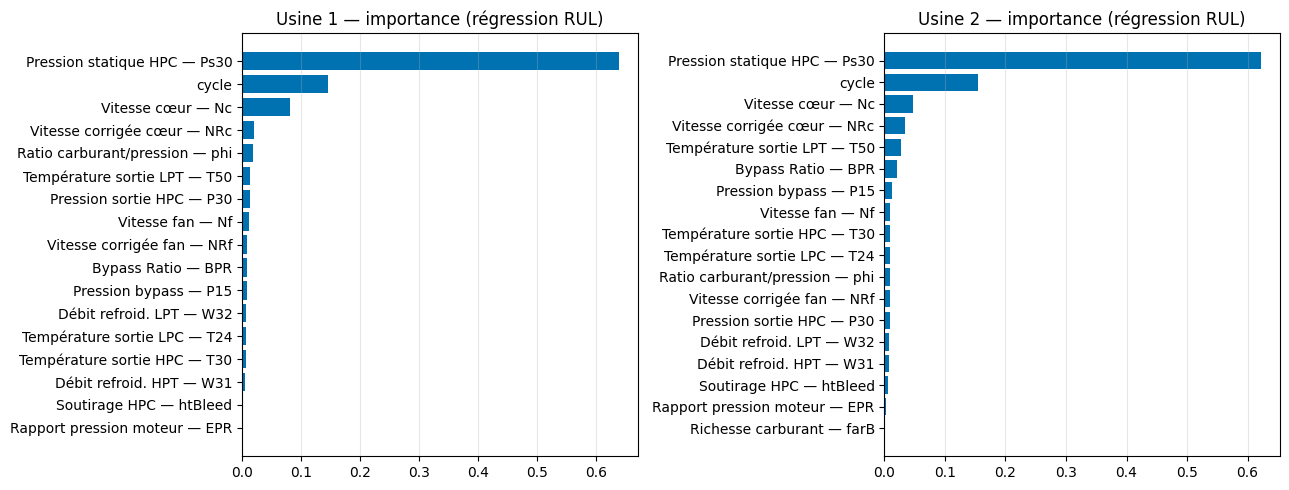

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (num, rf, feats) in zip(axes, [(1, rf_rul_U1, Features_U1),
                                       (2, rf_rul_U2, Features_U2)]):
    imp = pd.Series(rf.feature_importances_, index=feats).sort_values()
    ax.barh(imp.index, imp.values, color=outils.COULEURS['rf'])
    ax.set_title(f'Usine {num} — importance (régression RUL)')
    ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(outils.DOSSIER_FIGURES / 'rf_importances.png', dpi=120)
plt.show()

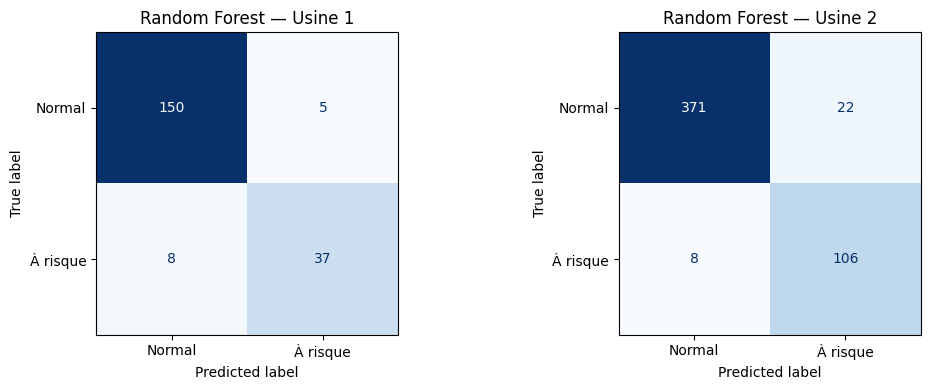

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (num, y_vrai, y_pred) in zip(axes, [(1, y_risk_vrai_U1, pred_risk_U1),
                                            (2, y_risk_vrai_U2, pred_risk_U2)]):
    cm = confusion_matrix(y_vrai, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'À risque']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Random Forest — Usine {num}')
plt.tight_layout()
plt.savefig(outils.DOSSIER_FIGURES / 'rf_confusion.png', dpi=120)
plt.show()

## Lecture et limites

- Gain net attendu sur la baseline en régression : les interactions entre capteurs paient.
- **Limites** connues de la forêt : le modèle stocke des centaines d'arbres (lourd en mémoire),
  et surtout il regarde chaque cycle **isolément** — il ne sait pas que le cycle 180 vient
  après le 179. Toute l'information de **tendance** (la dérive lente des capteurs) est perdue.
  C'est précisément ce que le LSTM (notebook 05) vient chercher.
- Comparaison complète dans le notebook **06 - Synthèse**.